<a href="https://colab.research.google.com/github/sabithamanoj/customer-churn-ml-deployment/blob/main/Notebooks/customer_churn_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📉 Customer Churn Prediction using Machine Learning

## 1. Project Introduction

Customer churn prediction is a machine learning approach used to identify customers who are likely to stop using a company's products or services.

Retaining existing customers is often more cost-effective than acquiring new customers. By predicting customers at risk of churn, businesses can take proactive actions such as personalized offers, improved customer support, and targeted retention strategies.

In this project, we build an end-to-end machine learning pipeline to predict customer churn using customer demographic information, account details, and service usage patterns.

The project covers:

- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature engineering
- Machine learning model development
- Model evaluation
- Model interpretation
- Model deployment preparation

### Machine Learning Problem

This is a **binary classification problem**:

- 0 → Customer stays
- 1 → Customer churns

### Workflow

 Dataset  
    ↓  
Data Cleaning  
    ↓  
Exploratory Analysis  
    ↓  
Feature Engineering  
    ↓  
Model Training  
    ↓  
Evaluation  
    ↓  
Model Deployment

## 2. Import Required Libraries

The following Python libraries are used for:

- Data manipulation
- Visualization
- Machine learning
- Model evaluation

In [60]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


## 3. Dataset Description

The Telco Customer Churn dataset contains information about customers and whether they discontinued their service. The dataset can be downloaded from Kaggle: https://www.kaggle.com/datasets/blastchar/telco-customer-churn

### Dataset Features

The dataset includes:

### Customer Information

- Gender
- Senior citizen status
- Partner
- Dependents

### Service Information

- Phone service
- Internet service
- Online security
- Technical support
- Streaming services

### Account Information

- Tenure
- Contract type
- Monthly charges
- Total charges
- Payment method

### Target Variable

Churn:

- Yes → Customer left the company
- No → Customer stayed

##4. Load Dataset

In [62]:
from google.colab import files

uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


Load:

In [63]:
df = pd.read_csv(
    "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##5. Initial Dataset Inspection

In [64]:
df.shape

(7043, 21)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [66]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 6. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the dataset before training machine learning models.

The objectives are to:

- Explore the structure of the dataset
- Understand customer characteristics
- Identify missing values
- Analyze the target variable
- Discover relationships between features and customer churn

### 6.1 Dataset Overview

Let's examine the size of the dataset, data types, and a few sample records.

In [67]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:\n")
print(df.columns.tolist())

print("\nFirst Five Rows:")
df.head()

Dataset Shape: (7043, 21)

Column Names:

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

First Five Rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 6.2 Missing Value Analysis

Missing values can negatively impact machine learning models.

The Telco Customer Churn dataset stores some missing values as blank strings rather than standard NaN values.

In [68]:
# Count blank values
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


There are blank values in "TotalCharges", convert them to numeric, blank values will become NaN

In [69]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

Check:

In [70]:
df.isnull().sum()
print(df["TotalCharges"].dtype)

float64


Verify:

In [71]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### 6.3. Duplicate Records

Duplicate customer records can bias model training.

We check whether duplicate observations exist.

In [72]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


### 6.4 Customer Churn Distribution

Understanding the balance between churned and retained customers helps identify whether the dataset is imbalanced.

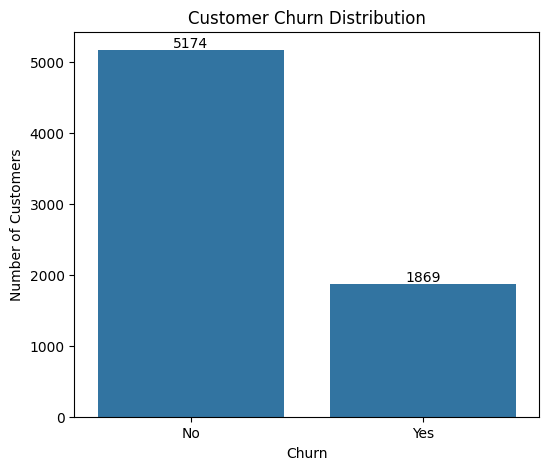

In [73]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [74]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    *100
)

print(churn_percentage)

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


**Observation**

The dataset is slightly imbalanced, with a larger proportion of customers remaining with the company than leaving.

This imbalance should be considered during model evaluation.

### Numerical Feature Distributions

We analyze the distributions of important numerical variables.

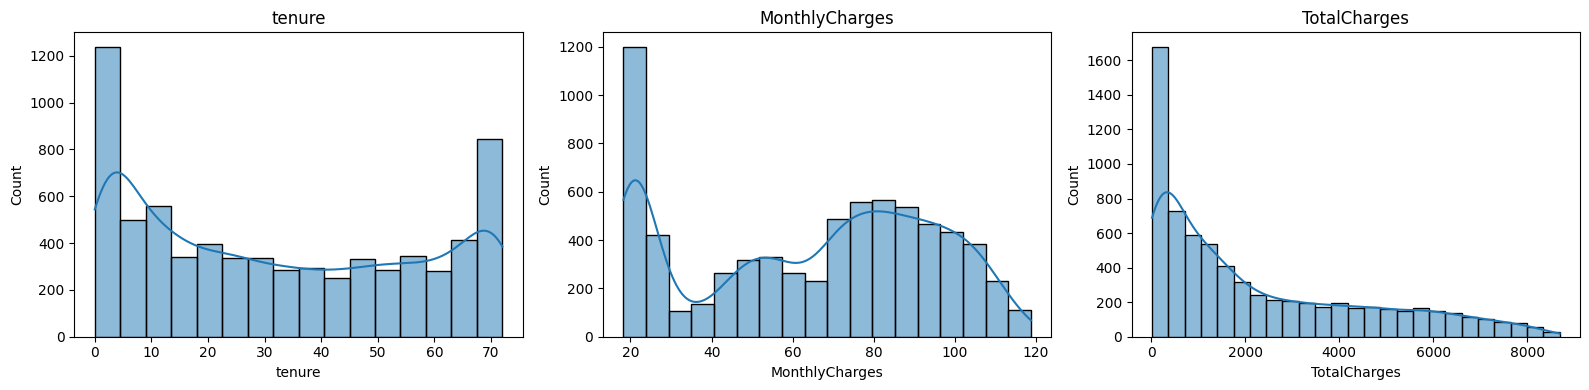

In [75]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,4)
)

for ax, feature in zip(axes, numerical_features):

    sns.histplot(
        df[feature],
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

6.5 Boxplots

Boxplots help identify outliers and compare distributions.

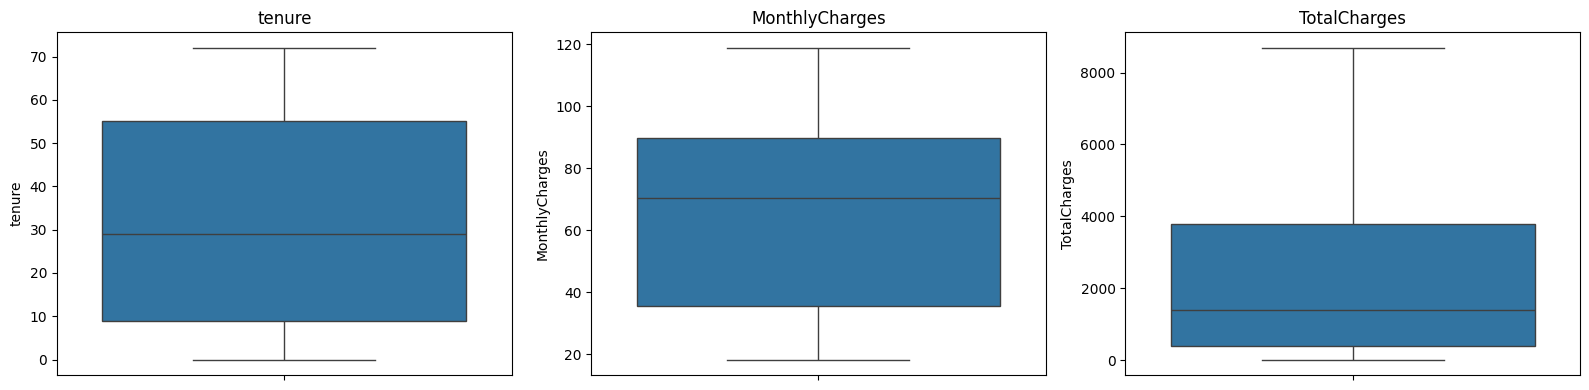

In [76]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16,4)
)

for ax, feature in zip(axes, numerical_features):

    sns.boxplot(
        y=df[feature],
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()

plt.show()

### Churn by Contract Type

Customers with different contract types may exhibit different churn behavior.

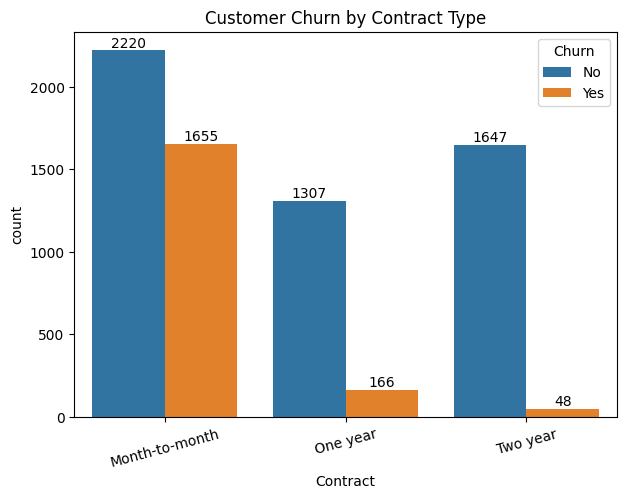

In [77]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Customer Churn by Contract Type")
plt.xticks(rotation=15)

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 6.6 Churn by Internet Service


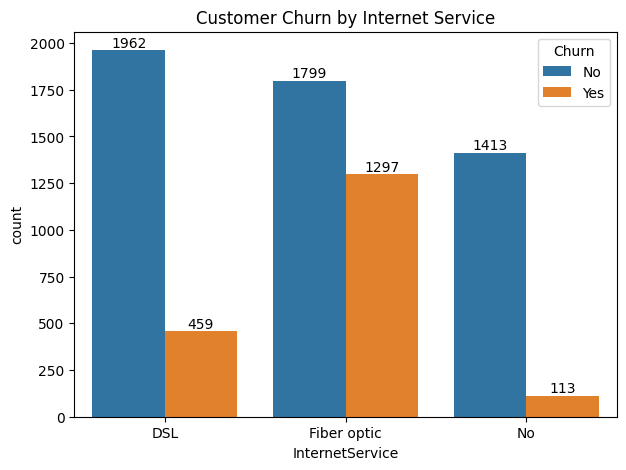

In [78]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=df,
    x="InternetService",
    hue="Churn"
)

plt.title("Customer Churn by Internet Service")

for container in ax.containers:
    ax.bar_label(container)

plt.show()

### 6.7 Churn by Internet Service

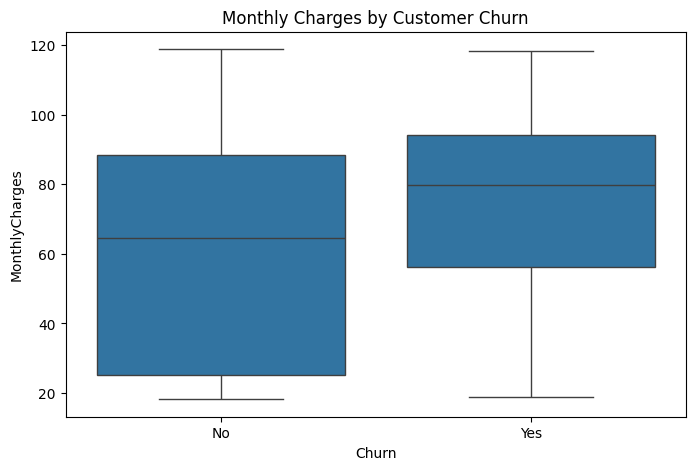

In [79]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges by Customer Churn")

plt.show()

**Observation**

Customers paying higher monthly charges may have a greater tendency to churn.

Pricing strategy could therefore influence customer retention.

### 6.8 Correlation Analysis

Since only numerical features are considered:

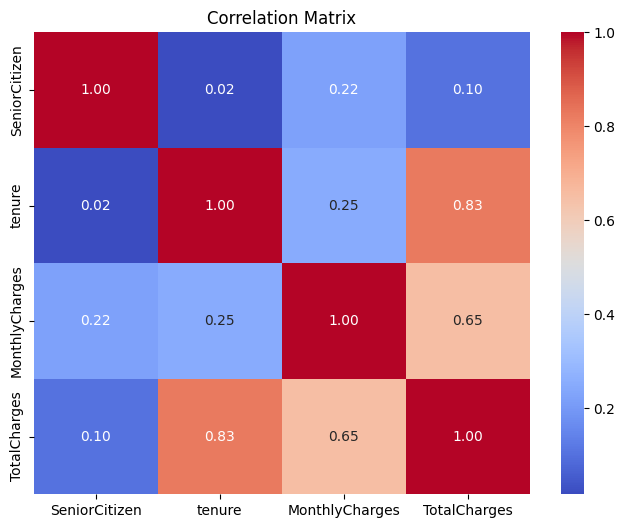

In [80]:
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### 6.9 Summary of EDA

### Key Findings

The exploratory analysis revealed several important insights:

- The dataset contains a small number of missing values in the `TotalCharges` column.
- The target variable is moderately imbalanced.
- Contract type appears strongly associated with customer churn.
- Customers with higher monthly charges tend to churn more frequently.
- Longer-tenure customers generally have lower churn rates.
- No duplicate records were identified.

These findings guide the preprocessing steps and feature engineering performed in the next section.

## 7. Data Preprocessing

Data preprocessing transforms raw customer data into a format that can be used by machine learning algorithms.

The preprocessing pipeline includes:

- Removing unnecessary features
- Handling missing values
- Encoding categorical variables
- Feature scaling
- Splitting the dataset into training and testing sets

### 7.1 Remove Unnecessary Columns

The `customerID` column uniquely identifies each customer but does not contribute to predicting customer churn. Therefore, it is removed before model training.

In [81]:
df = df.drop("customerID", axis=1)

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 7.2 Handle Missing Values

The dataset contains a small number of missing values in the `TotalCharges` column.

Since these represent less than 0.2% of the dataset, the corresponding rows are removed.

In [82]:
print("Dataset Shape Before:", df.shape)

df = df.dropna()

print("Dataset Shape After:", df.shape)

Dataset Shape Before: (7043, 20)
Dataset Shape After: (7032, 20)


### 7.3 Encode the Target Variable

The target variable `Churn` is converted into numerical values:

- No → 0
- Yes → **1**

In [83]:
df["Churn"] = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

df["Churn"].value_counts()

,count
Churn,
0,5163
1,1869


### 7.4 Encode Categorical Features

First identify categorical columns

In [84]:
categorical_columns = df.select_dtypes(include="object").columns

print(categorical_columns)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical representations using one-hot encoding.

Note: Using `drop_first=True` removes one category from each encoded feature to avoid multicollinearity, also known as the dummy variable trap.

In [85]:
df = pd.get_dummies(
    df,
    drop_first=True
)

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


### 7.5 Separate Features and Target Variable

The dataset is divided into:

- Features (X)
- Target variable (y)

In [86]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7032, 30)
Target: (7032,)


### 7.6 Train-Test Split

The dataset is divided into training and testing sets.

- Training set: 80%
- Testing set: 20%

The `stratify` parameter ensures that the class distribution remains consistent across both sets.

In [87]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape)
print("Testing Samples:", X_test.shape)

Training Samples: (5625, 30)
Testing Samples: (1407, 30)


### 7.7 Feature Scaling
Why Feature Scaling?

Feature scaling standardizes numerical variables so that they have comparable ranges.

This is particularly important for algorithms such as Logistic Regression and Support Vector Machines, which are sensitive to feature magnitudes. Tree-based models such as Random Forest and Gradient Boosting do not require feature scaling.


In [88]:
numeric_columns = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

Create copies

In [89]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

Scale:

In [90]:
scaler = StandardScaler()

X_train_scaled[numeric_columns] = scaler.fit_transform(
    X_train[numeric_columns]
)

X_test_scaled[numeric_columns] = scaler.transform(
    X_test[numeric_columns]
)

Verify:

In [91]:
X_train_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1413,0,1.321816,0.981556,1.659900,True,True,True,True,False,True,...,False,False,False,False,False,True,False,True,False,False
7003,0,-0.267410,-0.971546,-0.562252,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
3355,0,1.444064,0.837066,1.756104,False,True,False,True,False,True,...,False,False,False,False,False,True,False,True,False,False
4494,0,-1.204646,0.641092,-0.908326,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3541,0,0.669826,-0.808787,-0.101561,False,True,False,False,True,False,...,False,True,False,False,False,False,False,False,False,False


### 7.8 Preprocessing Summary

The dataset has now been prepared for machine learning by:

- Removing the customer identifier
- Handling missing values
- Encoding categorical variables
- Separating features and target labels
- Splitting the dataset into training and testing sets
- Scaling numerical features

The processed data is now ready for model training.